# AI304 Unsupervised Learning Lab
## Notebook 5: Interpretation, Societal Relevance & Ethical Analysis

In [1]:
# ─────────────────────────────────────────────
# Import libraries
# ─────────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns

sns.set_theme(style='whitegrid')
print("Libraries imported.")

Libraries imported.


In [2]:
# ─────────────────────────────────────────────
# Load final labelled dataset from Notebook 4
# ─────────────────────────────────────────────
df = pd.read_csv("final_labelled_features.csv", parse_dates=True, index_col='datetime')

feature_cols = [
    'mean_power', 'max_power', 'min_power', 'std_power',
    'peak_to_avg_ratio', 'avg_kitchen', 'avg_laundry', 'avg_hvac',
    'mean_voltage', 'std_voltage'
]

print(f"Loaded: {df.shape}")
df.head()

Loaded: (1433, 19)


,mean_power,max_power,min_power,std_power,peak_to_avg_ratio,avg_kitchen,avg_laundry,avg_hvac,mean_voltage,std_voltage,day_of_week,is_weekend,kmeans_cluster,kmedoids_cluster,dbscan_cluster,agg_cluster,month,anomaly,anomaly_score
datetime,,,,,,,,,,,,,,,,,,,
2006-12-16,3.053475,7.706,0.284,1.026338,2.523682,0.000000,1.378788,12.439394,236.243763,2.922896,5,1,2,0,-1,2,12,-1,-0.050030
2006-12-17,2.354486,7.064,0.206,1.205795,3.000230,1.411806,2.907639,9.264583,240.087028,4.051467,6,1,2,0,-1,2,12,1,0.031510
2006-12-18,1.530435,6.158,0.202,1.005074,4.023693,0.738194,1.820139,9.734722,241.231694,3.719576,0,0,2,0,-1,1,12,1,0.116558
2006-12-19,1.157079,7.840,0.194,1.237602,6.775682,0.582639,5.279167,4.303472,241.999313,3.069492,1,0,2,0,-1,2,12,1,0.052729
2006-12-20,1.545658,5.988,0.202,1.320968,3.874077,0.000000,1.838889,9.765972,242.308063,3.345704,2,0,2,0,-1,1,12,1,0.088733


---
## Part A: Cluster Archetype Profiling

We examine the mean feature values for each K-Means cluster to assign a  
real-world archetype label to each group.

In [3]:
# ─────────────────────────────────────────────
# Compute mean feature values per cluster
# This tells us the 'typical day' in each cluster.
# ─────────────────────────────────────────────
cluster_profiles = df.groupby('kmeans_cluster')[feature_cols].mean().round(3)
cluster_profiles

,mean_power,max_power,min_power,std_power,peak_to_avg_ratio,avg_kitchen,avg_laundry,avg_hvac,mean_voltage,std_voltage
kmeans_cluster,,,,,,,,,,
0,0.664,4.123,0.149,0.645,6.174,0.575,0.753,4.111,240.004,1.838
1,1.127,5.289,0.231,0.895,4.771,0.918,0.736,7.267,241.528,2.532
2,1.558,7.074,0.217,1.297,4.711,2.139,2.912,7.933,240.700,2.964


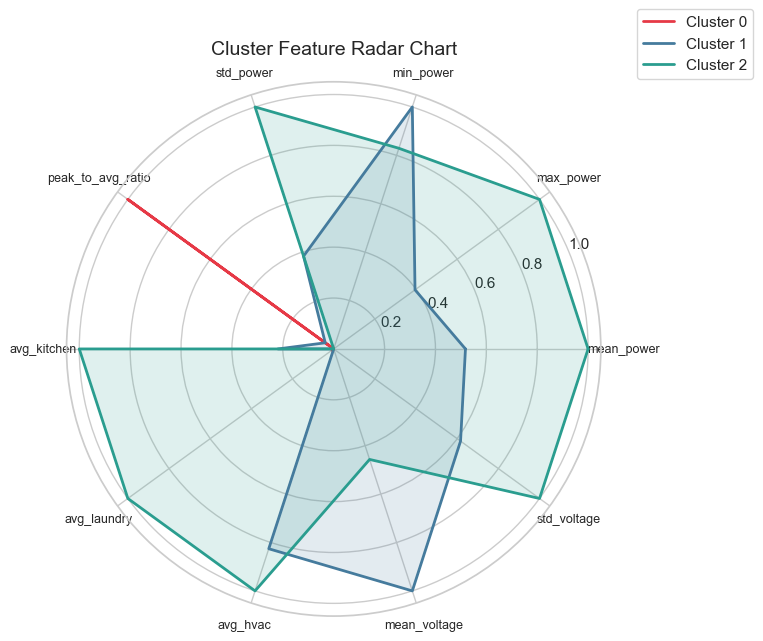

In [4]:
# ─────────────────────────────────────────────
# Visualise cluster profiles as a radar chart
# Each cluster's normalised feature fingerprint is overlaid
# to reveal its distinctive characteristics.
# ─────────────────────────────────────────────
from matplotlib.patches import FancyArrowPatch

# Normalise profiles to [0, 1] for radar chart
norm_profiles = (cluster_profiles - cluster_profiles.min()) / \
                (cluster_profiles.max() - cluster_profiles.min())

categories = list(norm_profiles.columns)
N = len(categories)
angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # Close the polygon

colors = ['#e63946', '#457b9d', '#2a9d8f']
fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

for idx, (cluster_id, row) in enumerate(norm_profiles.iterrows()):
    values = row.values.tolist()
    values += values[:1]
    ax.plot(angles, values, color=colors[idx], linewidth=2, label=f'Cluster {cluster_id}')
    ax.fill(angles, values, color=colors[idx], alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=9)
ax.set_title("Cluster Feature Radar Chart", fontsize=14, pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15))
plt.tight_layout()
plt.show()

---
## Part B: Weekend vs Weekday Cluster Distribution

Percentage of weekdays vs weekends within each cluster:
is_weekend      Weekday  Weekend
kmeans_cluster                  
0                  76.7     23.3
1                  80.7     19.3
2                  49.9     50.1


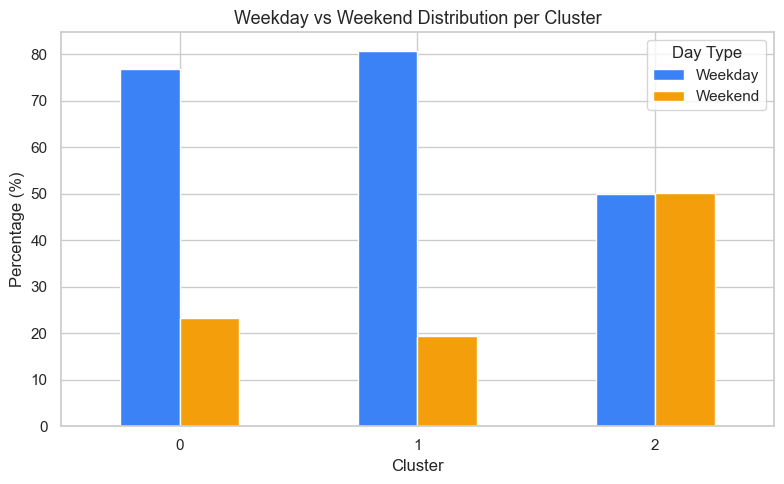

In [5]:
# ─────────────────────────────────────────────
# Analyse how weekday/weekend days distribute across clusters
# If weekend days concentrate in High-Usage cluster, this confirms
# that occupants are home more on weekends — a real behavioural insight.
# ─────────────────────────────────────────────
cross_tab = pd.crosstab(
    df['kmeans_cluster'],
    df['is_weekend'].map({0: 'Weekday', 1: 'Weekend'}),
    normalize='index'  # Row percentages
) * 100

print("Percentage of weekdays vs weekends within each cluster:")
print(cross_tab.round(1))

cross_tab.plot(kind='bar', figsize=(8, 5), color=['#3b82f6', '#f59e0b'], edgecolor='white')
plt.title("Weekday vs Weekend Distribution per Cluster", fontsize=13)
plt.ylabel("Percentage (%)")
plt.xlabel("Cluster")
plt.xticks(rotation=0)
plt.legend(title='Day Type')
plt.tight_layout()
plt.show()

---
## Part C: Anomaly Interpretation

In [6]:
# ─────────────────────────────────────────────
# Compare feature means: anomalous days vs normal days
# This tells us HOW anomalies differ from normal behaviour.
# ─────────────────────────────────────────────
anomaly_compare = df.groupby('anomaly')[feature_cols].mean().round(3)
anomaly_compare.index = ['Anomaly (-1)', 'Normal (+1)']
print("Feature comparison: Anomalous vs Normal days")
anomaly_compare

Feature comparison: Anomalous vs Normal days


,mean_power,max_power,min_power,std_power,peak_to_avg_ratio,avg_kitchen,avg_laundry,avg_hvac,mean_voltage,std_voltage
Anomaly (-1),1.446,5.976,0.219,1.138,4.831,2.253,2.890,6.214,240.117,2.718
Normal (+1),1.073,5.347,0.201,0.908,5.217,1.063,1.214,6.456,240.874,2.409


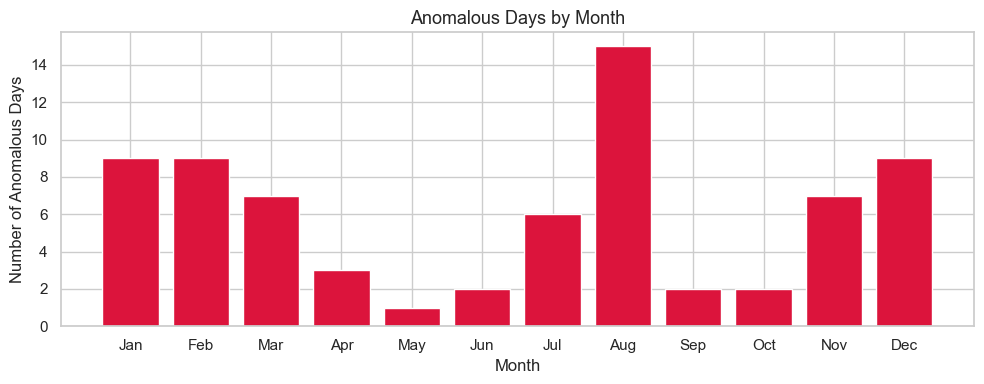

In [7]:
# ─────────────────────────────────────────────
# Month-wise distribution of anomalies
# If anomalies concentrate in December/January, it suggests
# extreme cold events driving unusually high consumption.
# ─────────────────────────────────────────────
anomaly_months = df[df['anomaly'] == -1].index.month.value_counts().sort_index()

month_names = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, ax = plt.subplots(figsize=(10, 4))
ax.bar(
    [month_names[m-1] for m in anomaly_months.index],
    anomaly_months.values,
    color='crimson', edgecolor='white'
)
ax.set_title("Anomalous Days by Month", fontsize=13)
ax.set_ylabel("Number of Anomalous Days")
ax.set_xlabel("Month")
plt.tight_layout()
plt.show()

In [8]:
# ─────────────────────────────────────────────
# Final Summary: Print cluster sizes and anomaly count
# ─────────────────────────────────────────────
print("=" * 50)
print("FINAL SUMMARY")
print("=" * 50)
print(f"Total days analysed:    {len(df)}")
print(f"\nK-Means Cluster Sizes:")
print(df['kmeans_cluster'].value_counts().sort_index().to_string())
print(f"\nAnomalies detected:     {(df['anomaly']==-1).sum()} days")
print(f"Normal days:            {(df['anomaly']==1).sum()} days")
print("=" * 50)

FINAL SUMMARY
Total days analysed:    1433

K-Means Cluster Sizes:
kmeans_cluster
0    451
1    615
2    367

Anomalies detected:     72 days
Normal days:            1361 days
